# 🎮 Doom vs Animal Crossing Meme Classifier
### Binary Image Classification from Scratch — Kaggle Competition

| Item | Detail |
|------|--------|
| Task | Binary Classification (0 = Doom, 1 = Animal Crossing) |
| Metric | Balanced Accuracy |
| Constraint | **No Pre-Trained Models** — trained entirely from scratch |
| Framework | TensorFlow / Keras |

---


In [9]:
# ── 1. Install Required Libraries ──
import subprocess, sys

_pkgs = ['tensorflow', 'scikit-learn', 'pandas', 'numpy',
         'matplotlib', 'seaborn', 'pillow']

for _pkg in _pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', _pkg, '-q'])

print("All packages ready.")



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


All packages ready.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [10]:
# ── 2. Imports ──
import os, shutil, zipfile, warnings, subprocess, sys

# Ensure every package is importable; auto-install if missing
def _ensure(pkg, import_name=None):
    import_name = import_name or pkg
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

_ensure('seaborn')
_ensure('Pillow', 'PIL')
_ensure('scikit-learn', 'sklearn')
_ensure('tensorflow')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import load_img, img_to_array

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")


TensorFlow : 2.21.0
GPU devices: []


In [11]:
# ── 3. Configuration — adjust BASE_DIR to your dataset path ──
# ⚠️  Change BASE_DIR to match your Kaggle input folder name
BASE_DIR   = '.'   # <-- CHANGE THIS

IMG_ZIP    = os.path.join(BASE_DIR, 'img.zip')
TRAIN_CSV  = os.path.join(BASE_DIR, 'train-label.csv')
TEST_CSV   = os.path.join(BASE_DIR, 'test-label.csv')
SAMPLE_CSV = os.path.join(BASE_DIR, 'submission.csv')

# ── Hyper-parameters ──
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
EPOCHS      = 120
SEED        = 42
VAL_SPLIT   = 0.20
NUM_CLASSES = 2
LR          = 1e-3
L2_REG      = 1e-4
N_TTA       = 15        # Test-Time Augmentation iterations

EXTRACT_DIR = os.path.join(BASE_DIR, 'img')
TRAIN_DIR   = os.path.join(BASE_DIR, 'data', 'train')
VAL_DIR     = os.path.join(BASE_DIR, 'data', 'val')
MODEL_PATH  = os.path.join(BASE_DIR, 'best_model.keras')


In [12]:
# ── 4. Load and Explore Labels ──
train_df  = pd.read_csv(TRAIN_CSV)
test_df   = pd.read_csv(TEST_CSV)
sample_df = pd.read_csv(SAMPLE_CSV)

print("=== train-label.csv ===")
print(train_df.head())
print(f"Shape : {train_df.shape}")
print(f"Label distribution:\n{train_df['label'].value_counts()}")
print(f"\nClass balance ratio: {train_df['label'].value_counts()[0] / train_df['label'].value_counts()[1]:.2f}")

print("\n=== test-label.csv ===")
print(test_df.head())
print(f"Shape : {test_df.shape}")

print("\n=== sample_submission.csv ===")
print(sample_df.head())


=== train-label.csv ===
   id                                  file  label
0   0  001bd5563b4511f0b16c00155d672fff.png      1
1   1  d13cde743b4411f0b16c00155d672fff.jpg      0
2   2  96f4bf1a3b4511f0b16c00155d672fff.jpg      1
3   3  43f18faa3b4511f0b16c00155d672fff.jpg      0
4   4  bf0df3a03b4411f0b16c00155d672fff.png      1
Shape : (1385, 3)
Label distribution:
label
0    707
1    678
Name: count, dtype: int64

Class balance ratio: 1.04

=== test-label.csv ===
     id                                  file  label
0  2078  082a7a903b4511f0b16c00155d672fff.jpg     -1
1  2079  0f9948383b4511f0b16c00155d672fff.png     -1
2  2080  eb1ae4b23b4411f0b16c00155d672fff.jpg     -1
3  2081  82f265443b4511f0b16c00155d672fff.jpg     -1
4  2082  ca5236363b4411f0b16c00155d672fff.jpg     -1
Shape : (1386, 3)

=== sample_submission.csv ===
     id  label
0  2078     -1
1  2079     -1
2  2080     -1
3  2081     -1
4  2082     -1


In [13]:
# ── 5. Extract Image Archive ──
os.makedirs(EXTRACT_DIR, exist_ok=True)

if len(os.listdir(EXTRACT_DIR)) == 0:
    print("Extracting img.zip ...")
    with zipfile.ZipFile(IMG_ZIP, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print("Done.")
else:
    print("Images already extracted — skipping.")

# Count extracted files
n_files = sum(1 for _, _, files in os.walk(EXTRACT_DIR) for f in files
              if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.webp', '.bmp')))
print(f"Total image files found: {n_files}")


Images already extracted — skipping.
Total image files found: 2771


In [14]:
# ── 6. Build filename → absolute-path mapping ──
print("Building path index (may take a moment)...")
path_map = {}
for root, _, files in os.walk(EXTRACT_DIR):
    for fname in files:
        path_map[fname] = os.path.join(root, fname)

def get_path(filename):
    return path_map.get(os.path.basename(filename), None)

train_df['path'] = train_df['file'].apply(get_path)
test_df['path']  = test_df['file'].apply(get_path)

print(f"Train paths resolved : {train_df['path'].notna().sum()} / {len(train_df)}")
print(f"Test  paths resolved : {test_df['path'].notna().sum()} / {len(test_df)}")

# Drop any rows where path was not found (should be 0)
train_df.dropna(subset=['path'], inplace=True)


Building path index (may take a moment)...
Train paths resolved : 1385 / 1385
Test  paths resolved : 1386 / 1386


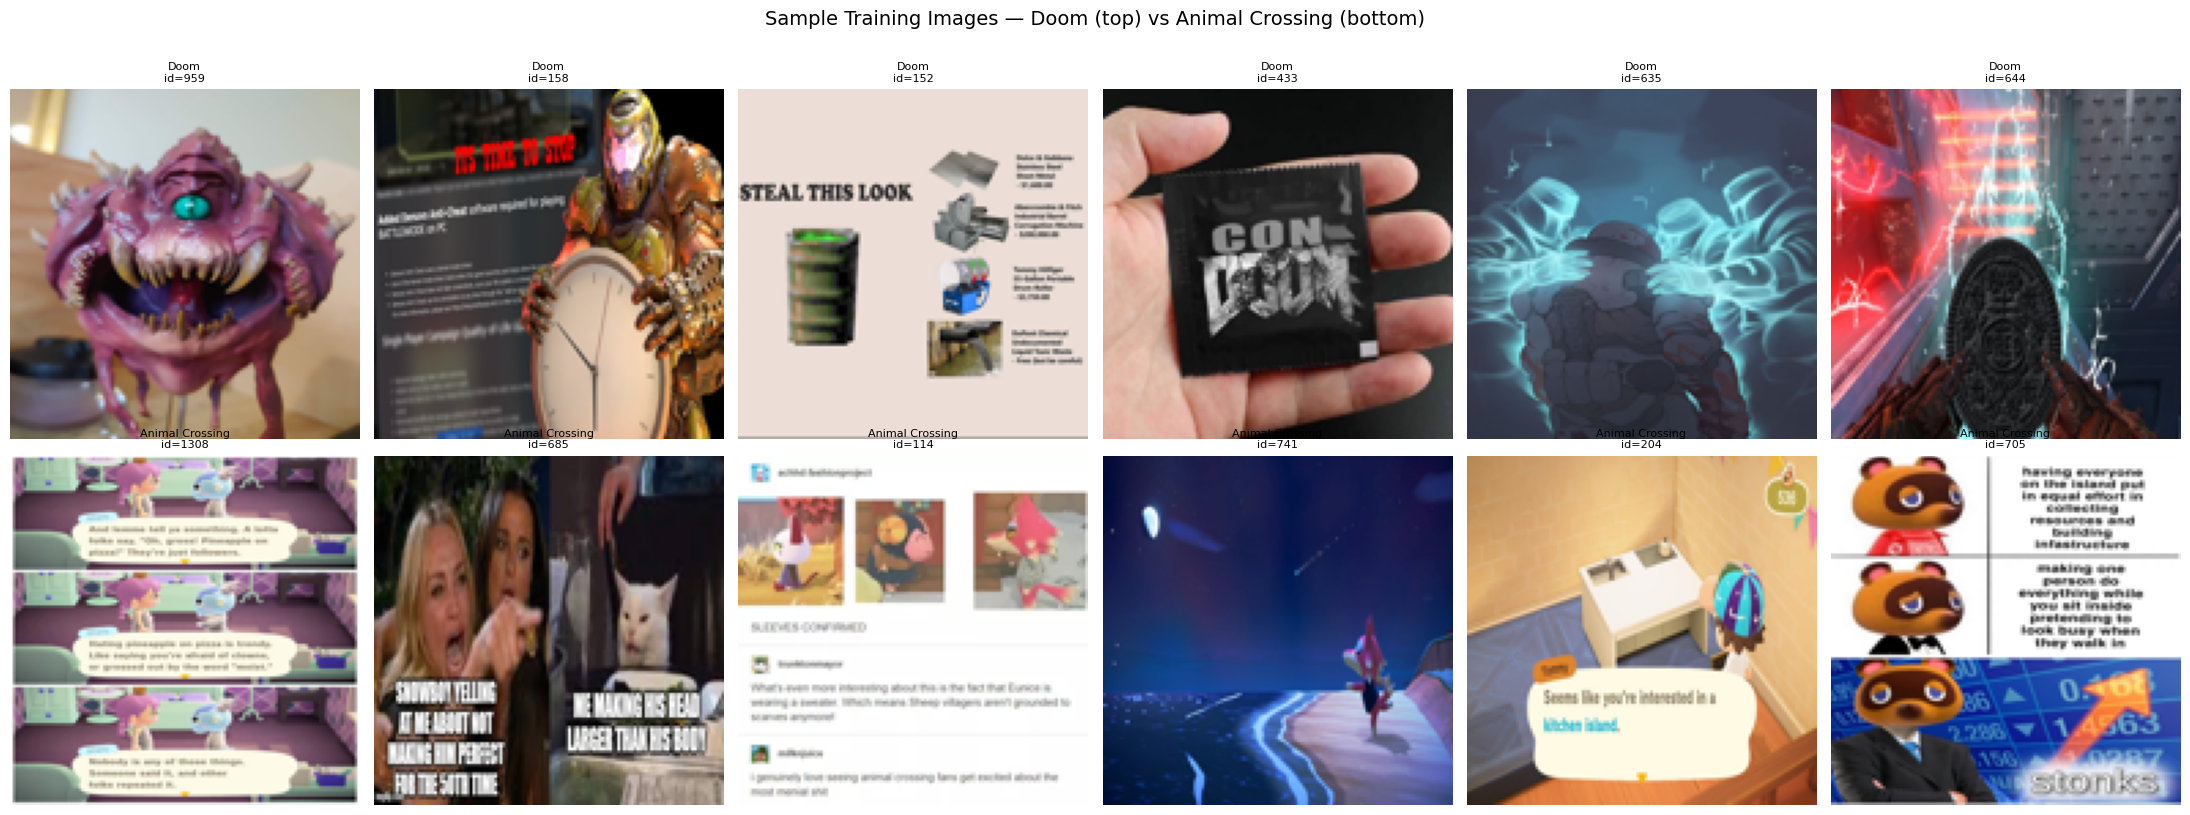

In [15]:
# ── 7. Visualise Sample Images ──
fig, axes = plt.subplots(2, 6, figsize=(22, 8))
for row_idx, (label_val, label_name) in enumerate([(0, 'Doom'), (1, 'Animal Crossing')]):
    subset = train_df[train_df['label'] == label_val].sample(6, random_state=SEED)
    for col_idx, (_, row) in enumerate(subset.iterrows()):
        ax = axes[row_idx][col_idx]
        try:
            img = Image.open(row['path']).convert('RGB').resize((128, 128))
            ax.imshow(img)
            ax.set_title(f'{label_name}\nid={row["id"]}', fontsize=8)
        except Exception:
            ax.set_title('Load error')
        ax.axis('off')
plt.suptitle('Sample Training Images — Doom (top) vs Animal Crossing (bottom)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [16]:
# ── 8. Organise Images for image_dataset_from_directory ──
for split_dir in [TRAIN_DIR, VAL_DIR]:
    for lbl in ['0', '1']:
        os.makedirs(os.path.join(split_dir, lbl), exist_ok=True)

train_split, val_split = train_test_split(
    train_df,
    test_size  = VAL_SPLIT,
    random_state = SEED,
    stratify   = train_df['label']
)
print(f"Train : {len(train_split)} | Val : {len(val_split)}")
print(f"Train label dist:\n{train_split['label'].value_counts()}")

def copy_to_dir(df, base_dir):
    count = 0
    for _, row in df.iterrows():
        src = row['path']
        dst = os.path.join(base_dir, str(row['label']), os.path.basename(src))
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
        count += 1
    return count

if len(os.listdir(os.path.join(TRAIN_DIR, '0'))) == 0:
    print("Copying train images ...")
    copy_to_dir(train_split, TRAIN_DIR)
    print("Copying val images ...")
    copy_to_dir(val_split, VAL_DIR)
    print("Done.")
else:
    print("Directories already populated — skipping copy.")


Train : 1108 | Val : 277
Train label dist:
label
0    566
1    542
Name: count, dtype: int64
Copying train images ...
Copying val images ...
Done.


In [17]:
# ── 9. Create TensorFlow Datasets ──
train_ds_raw = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size   = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    seed         = SEED,
    shuffle      = True,
    label_mode   = 'int'
)

val_ds_raw = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size   = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    seed         = SEED,
    shuffle      = False,
    label_mode   = 'int'
)

class_names = train_ds_raw.class_names
print(f"Detected class names : {class_names}")


Found 1108 files belonging to 2 classes.
Found 277 files belonging to 2 classes.
Detected class names : ['0', '1']


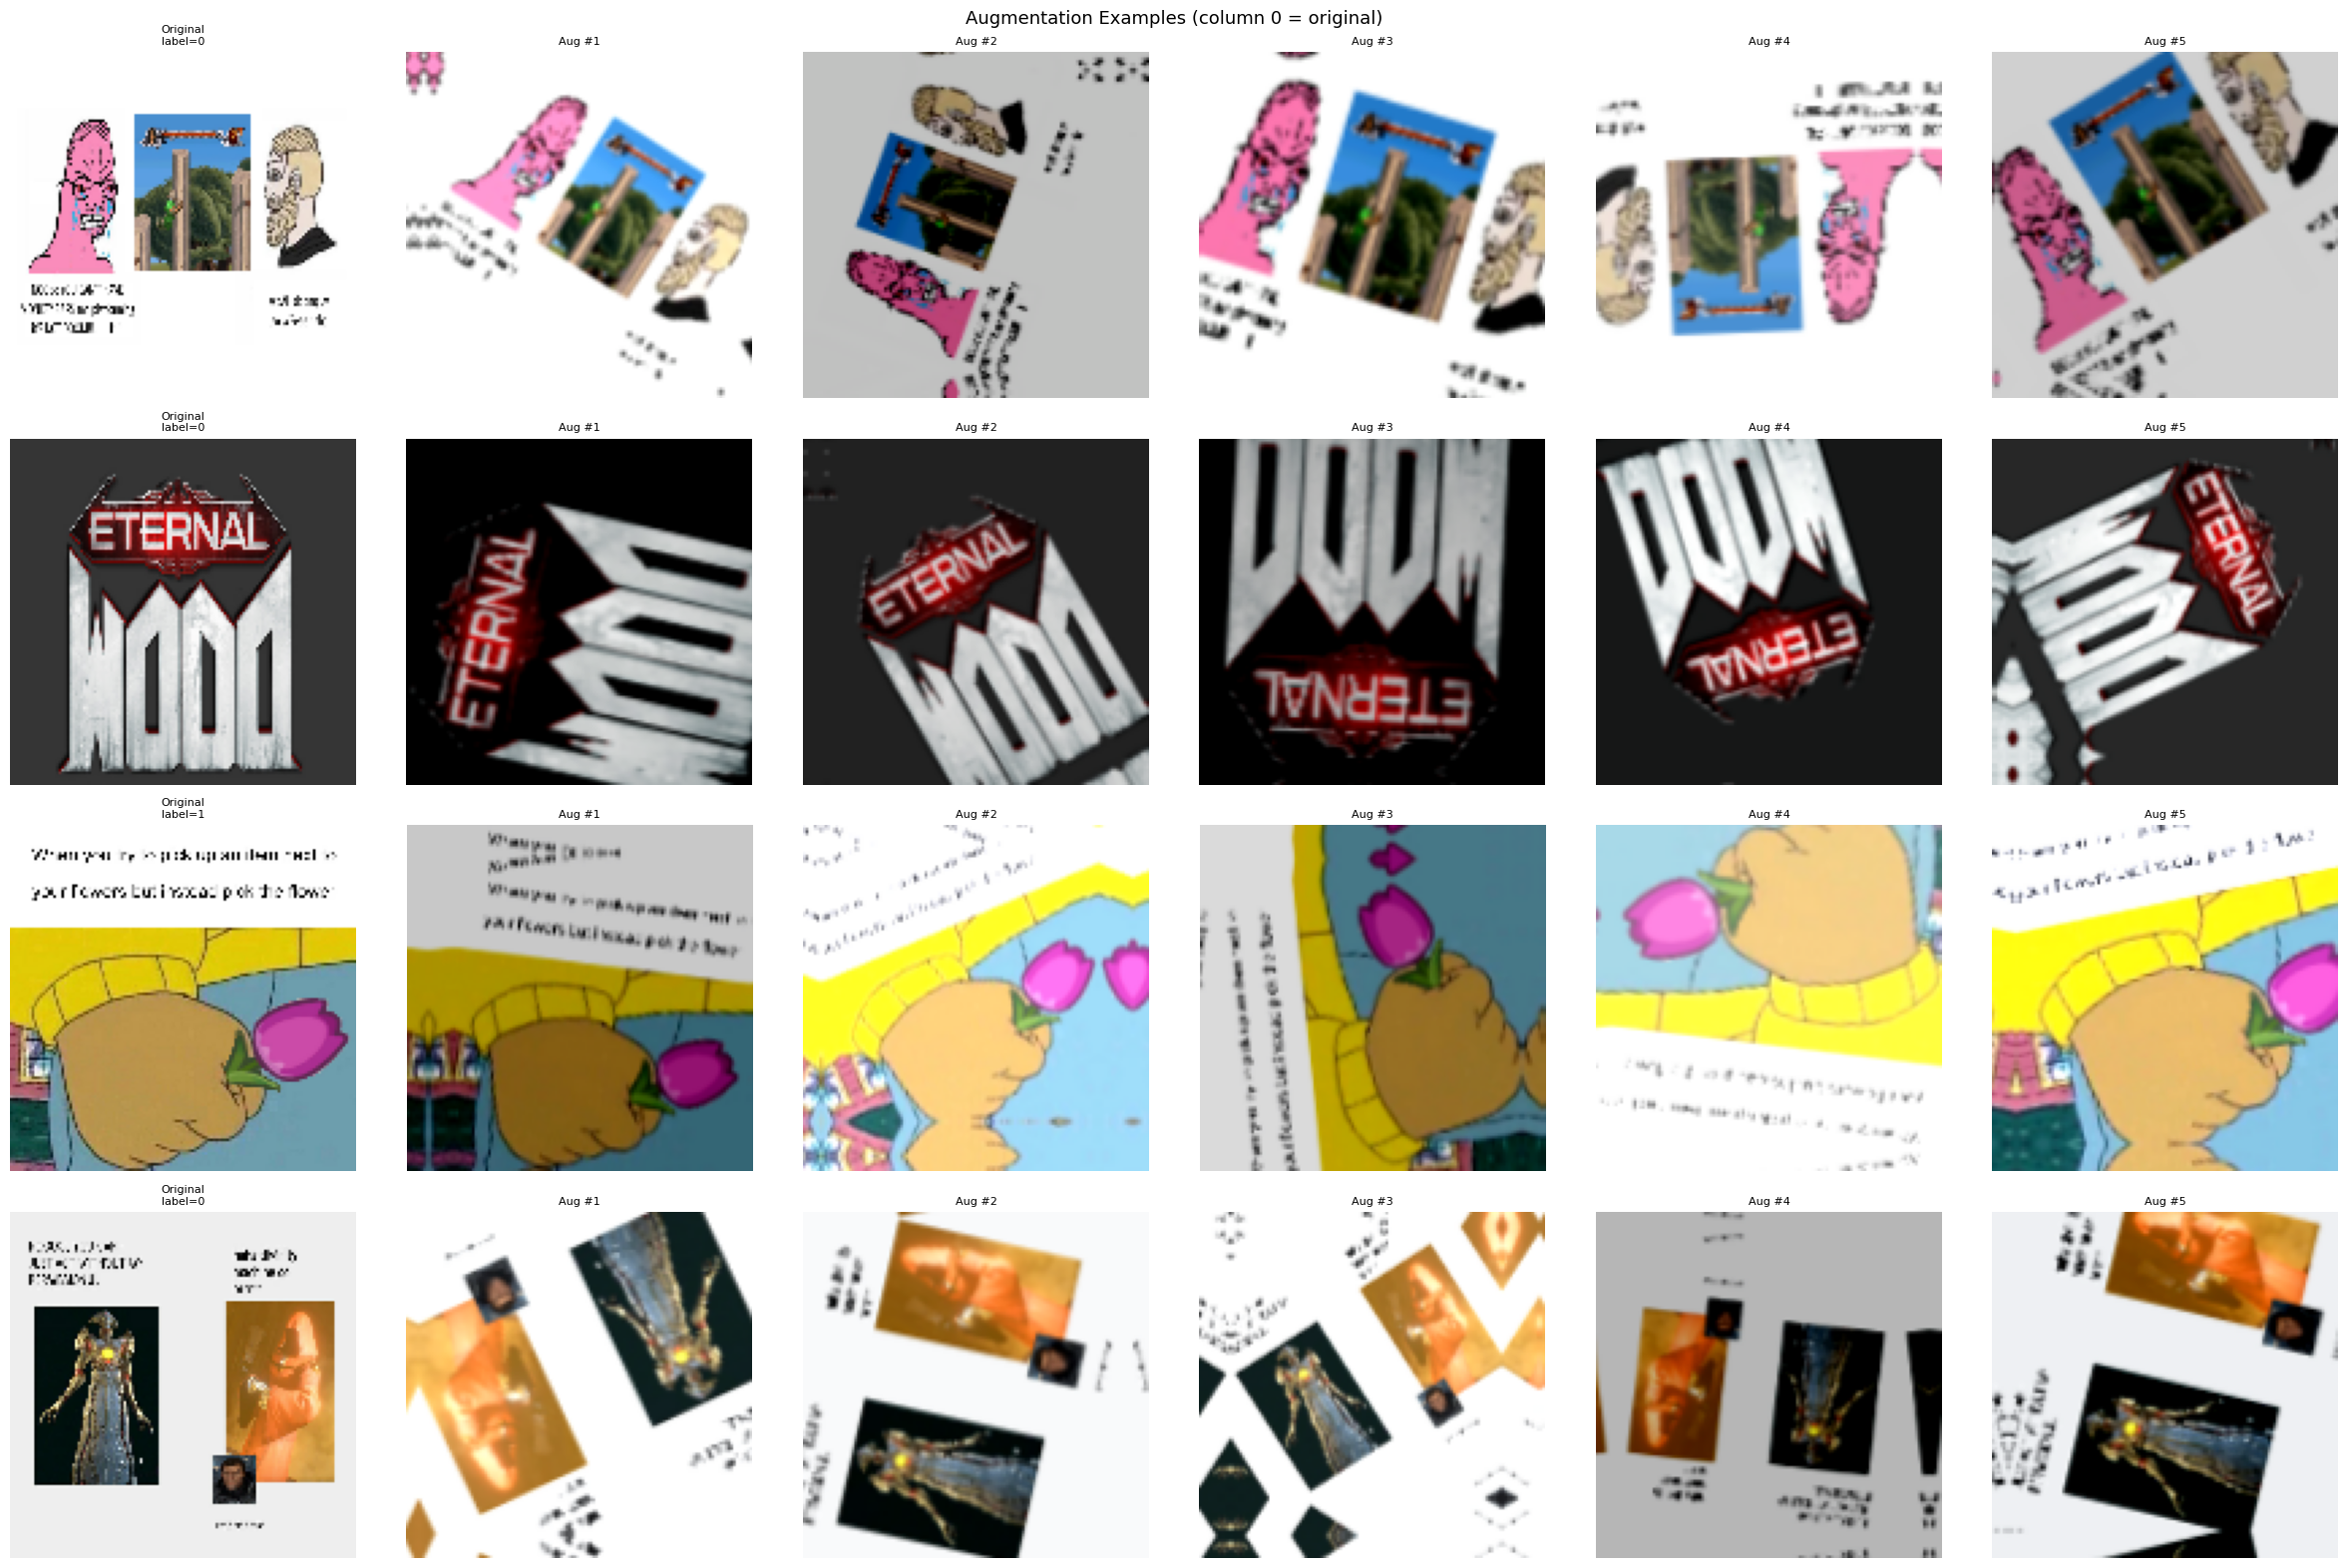

In [18]:
# ── 10. Data Augmentation & Normalisation Pipeline ──
augmentation_layer = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.25),
    layers.RandomZoom((-0.25, 0.30)),
    layers.RandomBrightness(0.30),
    layers.RandomContrast(0.30),
    layers.RandomTranslation(height_factor=0.10, width_factor=0.10),
], name='augmentation')

AUTOTUNE = tf.data.AUTOTUNE

def aug_norm(image, label):
    image = augmentation_layer(image, training=True)
    return tf.cast(image, tf.float32) / 255.0, label

def normalize(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

train_ds = (train_ds_raw
    .map(aug_norm, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(buffer_size=2048, seed=SEED)
    .prefetch(AUTOTUNE)
)

val_ds = (val_ds_raw
    .map(normalize, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

# ── Visualise augmented samples ──
sample_imgs, sample_lbls = next(iter(train_ds_raw))
sample_imgs = sample_imgs[:4].numpy()

fig, axes = plt.subplots(4, 6, figsize=(24, 16))
for i in range(4):
    axes[i][0].imshow(sample_imgs[i].astype(np.uint8))
    axes[i][0].set_title(f'Original\nlabel={class_names[sample_lbls[i]]}', fontsize=8)
    axes[i][0].axis('off')
    for j in range(1, 6):
        aug = augmentation_layer(tf.expand_dims(sample_imgs[i], 0), training=True)[0]
        axes[i][j].imshow(tf.cast(aug, tf.uint8).numpy())
        axes[i][j].set_title(f'Aug #{j}', fontsize=8)
        axes[i][j].axis('off')
plt.suptitle('Augmentation Examples (column 0 = original)', fontsize=13)
plt.tight_layout()
plt.show()


In [19]:
# ── 11. Custom CNN Architecture (built entirely from scratch) ──
# No pre-trained weights — every parameter is randomly initialised.

def conv_block(x, filters, n_convs=2, reg=L2_REG):
    """Double-convolution block with BN + ReLU."""
    for _ in range(n_convs):
        x = layers.Conv2D(
            filters, 3, padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(reg),
            kernel_initializer='he_normal'
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
    return x

def build_model(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES, reg=L2_REG):
    inputs = keras.Input(shape=input_shape, name='input')

    # ── Stem ──────────────────────────────────────────────────────────
    # 128x128 → 64x64
    x = conv_block(inputs, 32,  n_convs=2, reg=reg)
    x = layers.MaxPooling2D(2, name='pool1')(x)
    x = layers.SpatialDropout2D(0.10)(x)

    # ── Block 2 ────────────────────────────────────────────────────────
    # 64x64 → 32x32
    x = conv_block(x, 64, n_convs=2, reg=reg)
    x = layers.MaxPooling2D(2, name='pool2')(x)
    x = layers.SpatialDropout2D(0.15)(x)

    # ── Block 3 ────────────────────────────────────────────────────────
    # 32x32 → 16x16
    x = conv_block(x, 128, n_convs=3, reg=reg)
    x = layers.MaxPooling2D(2, name='pool3')(x)
    x = layers.SpatialDropout2D(0.20)(x)

    # ── Block 4 ────────────────────────────────────────────────────────
    # 16x16 → 8x8
    x = conv_block(x, 256, n_convs=3, reg=reg)
    x = layers.MaxPooling2D(2, name='pool4')(x)
    x = layers.SpatialDropout2D(0.20)(x)

    # ── Block 5 ────────────────────────────────────────────────────────
    # 8x8 → 4x4
    x = conv_block(x, 512, n_convs=2, reg=reg)
    x = layers.MaxPooling2D(2, name='pool5')(x)

    # ── Dual Global Pooling ────────────────────────────────────────────
    avg_pool = layers.GlobalAveragePooling2D(name='gap')(x)
    max_pool = layers.GlobalMaxPooling2D(name='gmp')(x)
    x = layers.Concatenate(name='concat_pool')([avg_pool, max_pool])  # 1024-d

    # ── Classifier Head ───────────────────────────────────────────────
    x = layers.Dense(512, use_bias=False, kernel_regularizer=regularizers.l2(reg),
                     kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.50)(x)

    x = layers.Dense(256, use_bias=False, kernel_regularizer=regularizers.l2(reg),
                     kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.40)(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return keras.Model(inputs, outputs, name='CustomCNN_FromScratch')

model = build_model()
model.summary()
print(f"\nTotal trainable parameters: {model.count_params():,}")


Model: "CustomCNN_FromScratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        864 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 64, 64,    │          0 │ pool1[0][0]       │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,432 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_1 │ (None, 32, 32,    │          0 │ pool2[0][0]     

 Total params: 6,115,938 (23.33 MB)

 Trainable params: 6,109,666 (23.31 MB)

 Non-trainable params: 6,272 (24.50 KB)


Total trainable parameters: 6,115,938


In [20]:
# ── 12. Class Weights (for Balanced Accuracy optimisation) ──
train_labels_arr = train_split['label'].values
cw_vals = compute_class_weight('balanced', classes=np.unique(train_labels_arr), y=train_labels_arr)
class_weight_dict = dict(enumerate(cw_vals))
print(f"Class weights: {class_weight_dict}")
# Heavier weight on minority class ensures the model can't ignore it


Class weights: {0: np.float64(0.9787985865724381), 1: np.float64(1.022140221402214)}


In [21]:
# ── 13. Compile & Train ──
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR),
    loss      = keras.losses.SparseCategoricalCrossentropy(),
    metrics   = ['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor             = 'val_loss',
        patience            = 20,
        restore_best_weights= True,
        verbose             = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 7,
        min_lr   = 1e-7,
        verbose  = 1
    ),
    ModelCheckpoint(
        MODEL_PATH,
        monitor        = 'val_loss',
        save_best_only = True,
        verbose        = 1
    ),
]

print("Training started...")
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    class_weight    = class_weight_dict,
    verbose         = 1
)
print("Training finished.")


Training started...
Epoch 1/120


W0000 00:00:1779447769.765583 1481516 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779447769.991773 1481517 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779447770.012129 1481524 png_io.cc:96] PNG warning: iCCP: extra compressed data
W0000 00:00:1779447770.030302 1481525 png_io.cc:96] PNG warning: iCCP: extra compressed data
W0000 00:00:1779447770.852986 1481522 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779447771.033443 1481518 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779447771.761556 1481519 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779447772.399457 1481520 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5237 - loss: 1.5725

W0000 00:00:1779447826.147373 1482167 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1779447826.826687 1482166 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile



Epoch 1: val_loss improved from None to 142.95189, saving model to ./best_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5370 - loss: 1.5341 - val_accuracy: 0.4910 - val_loss: 142.9519 - learning_rate: 0.0010
Epoch 2/120
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5920 - loss: 1.3760
Epoch 2: val_loss improved from 142.95189 to 1.97734, saving model to ./best_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.5830 - loss: 1.4004 - val_accuracy: 0.6318 - val_loss: 1.9773 - learning_rate: 0.0010
Epoch 3/120
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5958 - loss: 1.3634
Epoch 3: val_loss did not improve from 1.97734
35/35 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.5921 - loss: 1.3989 - val_accuracy: 0.6245 - val_loss: 2.2599 - learning_rate: 0.0010
Epoch 4/120
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5813 - loss: 1.3807
Epoch 4: val_loss improved from 1.97734 to 1.35497, saving model to ./best_model.keras
35/35 ━━━━━━━━━━━━━

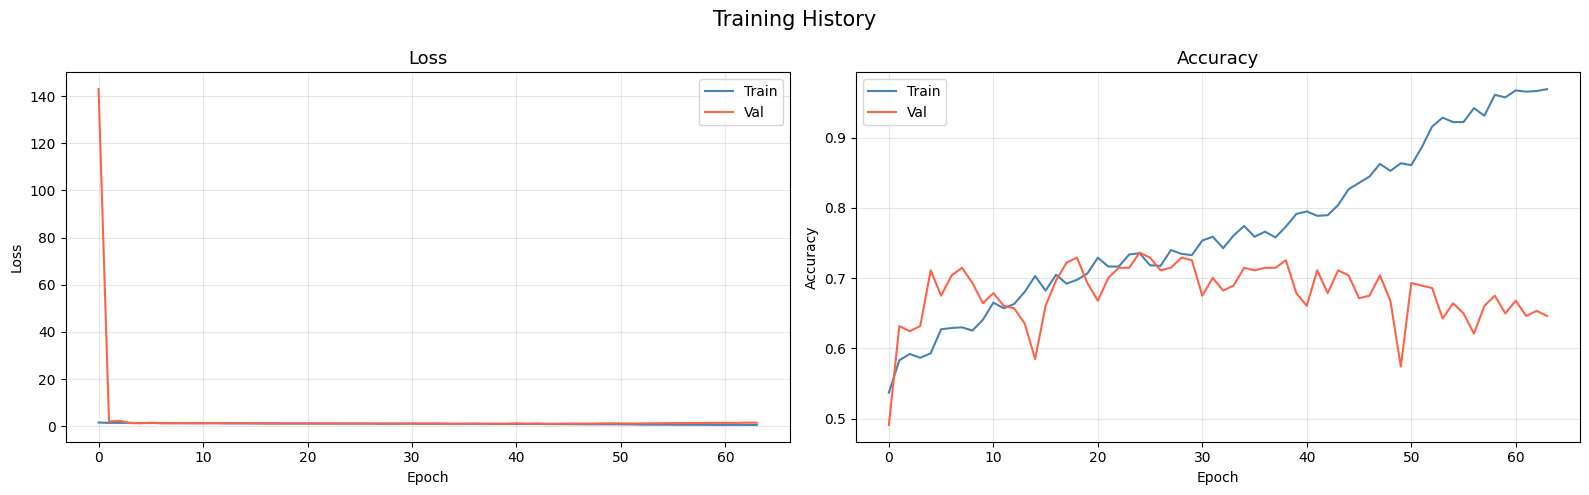

Best val accuracy : 0.7365
Best val loss     : 1.0173


In [23]:
# ── 14. Training Curves ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history.history['loss'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val',   color='tomato')
axes[0].set_title('Loss', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val',   color='tomato')
axes[1].set_title('Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training History', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'training_curves.png'), dpi=100)
plt.show()

print(f"Best val accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Best val loss     : {min(history.history['val_loss']):.4f}")


  Validation Balanced Accuracy : 0.7102

                     precision    recall  f1-score   support

           Doom (0)       0.70      0.77      0.73       141
Animal Crossing (1)       0.73      0.65      0.69       136

           accuracy                           0.71       277
          macro avg       0.71      0.71      0.71       277
       weighted avg       0.71      0.71      0.71       277



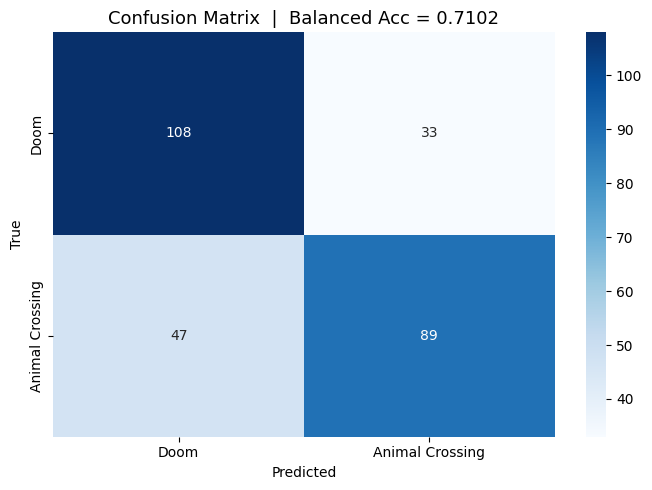

In [25]:
# ── 15. Validation Evaluation ──
best_model = keras.models.load_model(MODEL_PATH)

val_preds_list, val_labels_list = [], []
for x_batch, y_batch in val_ds:
    probs = best_model.predict(x_batch, verbose=0)
    val_preds_list.extend(np.argmax(probs, axis=1))
    val_labels_list.extend(y_batch.numpy())

val_preds  = np.array(val_preds_list)
val_labels = np.array(val_labels_list)

ba = balanced_accuracy_score(val_labels, val_preds)
print(f"{'='*45}")
print(f"  Validation Balanced Accuracy : {ba:.4f}")
print(f"{'='*45}")
print()
print(classification_report(val_labels, val_preds,
                             target_names=['Doom (0)', 'Animal Crossing (1)']))

cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Doom', 'Animal Crossing'],
            yticklabels=['Doom', 'Animal Crossing'])
plt.title(f'Confusion Matrix  |  Balanced Acc = {ba:.4f}', fontsize=13)
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'confusion_matrix.png'), dpi=100)
plt.show()


In [26]:
# ── 16. (Optional) Re-train on Full Dataset for Final Submission ──
# Uncomment the block below to squeeze out extra performance.
# ⚠️  Only do this AFTER tuning is complete — val metrics become unavailable.

# RETRAIN_FULL = True   # set to True to enable
RETRAIN_FULL = False

if RETRAIN_FULL:
    # Combine train + val into one directory
    FULL_DIR = os.path.join(BASE_DIR, 'data', 'full')
    for lbl in ['0', '1']:
        os.makedirs(os.path.join(FULL_DIR, lbl), exist_ok=True)
    copy_to_dir(train_df, FULL_DIR)   # all labelled images

    full_ds = keras.utils.image_dataset_from_directory(
        FULL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        seed=SEED, shuffle=True, label_mode='int'
    )
    full_ds = (full_ds
        .map(aug_norm, num_parallel_calls=AUTOTUNE)
        .cache().shuffle(2048, seed=SEED).prefetch(AUTOTUNE)
    )

    cw_full = compute_class_weight('balanced',
                                    classes=np.unique(train_df['label'].values),
                                    y=train_df['label'].values)

    best_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR * 0.1),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    best_epoch = len(history.history['val_loss'])
    best_model.fit(full_ds, epochs=best_epoch,
                   class_weight=dict(enumerate(cw_full)), verbose=1)
    best_model.save(os.path.join(BASE_DIR, 'full_retrained_model.keras'))
    print("Full retrain complete.")


In [27]:
# ── 17. Load Test Images in Submission Order ──
def load_test_images(df, img_size=IMG_SIZE):
    images = []
    for _, row in df.iterrows():
        try:
            img = load_img(row['path'], target_size=img_size)
            arr = img_to_array(img) / 255.0
        except Exception as e:
            print(f"  WARNING: Could not load {row['path']}: {e}")
            arr = np.zeros((*img_size, 3), dtype=np.float32)
        images.append(arr)
    return np.array(images, dtype=np.float32)

print("Loading test images ...")
test_images = load_test_images(test_df)
print(f"Test tensor shape : {test_images.shape}")


Loading test images ...
Test tensor shape : (1386, 128, 128, 3)


Running TTA (15 augmented passes + 1 clean pass) ...
  TTA step 5/15 done
  TTA step 10/15 done
  TTA step 15/15 done

Prediction distribution:
  Label 0 (Doom) : 169  (12.2%)
  Label 1 (Animal Crossing) : 1217  (87.8%)


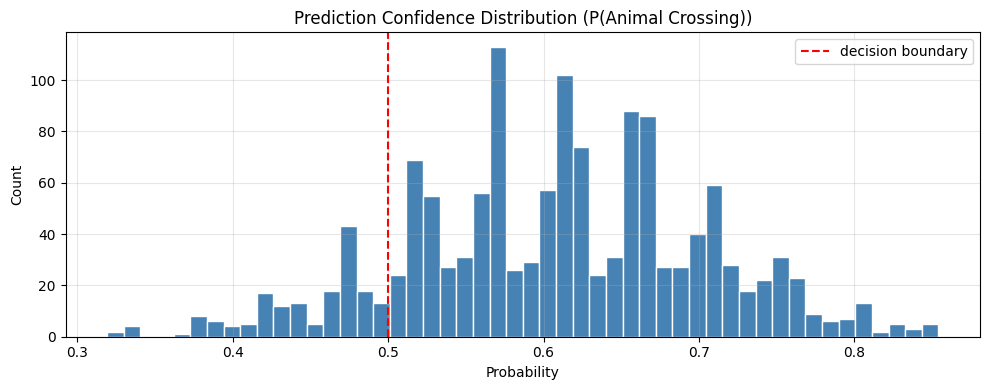

In [28]:
# ── 18. Predict with Test-Time Augmentation (TTA) ──
# Averaging multiple augmented forward passes reduces variance and
# improves balanced accuracy — especially for ambiguous memes.

def tta_predict(model, images, aug_fn, n_tta=N_TTA, batch_size=BATCH_SIZE):
    """
    Returns averaged softmax probabilities over:
      1 clean pass  +  n_tta augmented passes
    """
    all_probs = []

    # Clean prediction
    probs = model.predict(images, batch_size=batch_size, verbose=0)
    all_probs.append(probs)

    # Augmented predictions
    for i in range(n_tta):
        aug_imgs = aug_fn(images, training=True).numpy()
        probs    = model.predict(aug_imgs, batch_size=batch_size, verbose=0)
        all_probs.append(probs)
        if (i + 1) % 5 == 0:
            print(f"  TTA step {i+1}/{n_tta} done")

    return np.mean(all_probs, axis=0)   # shape: (N, num_classes)

print(f"Running TTA ({N_TTA} augmented passes + 1 clean pass) ...")
test_probs  = tta_predict(best_model, test_images, augmentation_layer, n_tta=N_TTA)
test_labels = np.argmax(test_probs, axis=1)

print(f"\nPrediction distribution:")
unique, counts = np.unique(test_labels, return_counts=True)
for u, c in zip(unique, counts):
    name = 'Doom' if u == 0 else 'Animal Crossing'
    print(f"  Label {u} ({name}) : {c}  ({100*c/len(test_labels):.1f}%)")

# Confidence histogram
plt.figure(figsize=(10, 4))
plt.hist(test_probs[:, 1], bins=50, color='steelblue', edgecolor='white')
plt.axvline(0.5, color='red', linestyle='--', label='decision boundary')
plt.title('Prediction Confidence Distribution (P(Animal Crossing))', fontsize=12)
plt.xlabel('Probability'); plt.ylabel('Count')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()


In [29]:
# ── 19. Build submission.csv ──
submission = pd.DataFrame({
    'id'   : test_df['id'].values,
    'label': test_labels
})

# Align with sample_submission order (required by Kaggle)
submission = (submission
    .set_index('id')
    .loc[sample_df['id']]
    .reset_index()
)

SUBMISSION_PATH = os.path.join(BASE_DIR, 'submission3.csv')
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"Saved: {SUBMISSION_PATH}")
print(submission.head(10))
print(f"\nShape          : {submission.shape}")
print(f"Label dist:\n{submission['label'].value_counts()}")


Saved: ./submission3.csv
     id  label
0  2078      1
1  2079      1
2  2080      1
3  2081      1
4  2082      1
5  2083      1
6  2084      1
7  2085      1
8  2086      1
9  2087      1

Shape          : (1386, 2)
Label dist:
label
1    1217
0     169
Name: count, dtype: int64


In [30]:
# ── 20. Final Sanity Check ──
df_check = pd.read_csv(SUBMISSION_PATH)
assert list(df_check.columns) == ['id', 'label'], "Column names mismatch!"
assert len(df_check) == len(sample_df),           "Row count mismatch!"
assert df_check['label'].isin([0, 1]).all(),       "Invalid label values!"
assert (df_check['id'] == sample_df['id']).all(),  "ID order mismatch!"

print("✅ All checks passed — submission.csv is valid.")
print(df_check.head())


✅ All checks passed — submission.csv is valid.
     id  label
0  2078      1
1  2079      1
2  2080      1
3  2081      1
4  2082      1
